# Multi-Device Synchronization
This example illustrates how to resynchronize multiple Redpitaya-125 via the daisy chan connectors (gen 1: SATA, gen 2: USB-C) to an accuracy of +/- 1 clk cycle between neighboring devices. 

In detail, a pair of Redpitaya-125 a resynchronized and after a variable hold time output a gaussian pulse on their RF outputs. Both pulses are acquired on the RF inputs of the first device and the corresponding arrival times a estimated, expecting a spread of +/- 1 clk cycle at low hold times but increasing at larger timescales due to relative drifts in the frequency of the Repidtaya reference clocks. 

Required hardware connection (see [README](../README.md) for IO Names and Pin Mapping):
*  SMA cable between rp_0.rf_out_0 <-> rp_0.rf_in_0
*  SMA cable between rp_1.rf_out_0 <-> rp_0.rf_in_1
*  SATA / USB-C cable rp_0.daisy_0 <-> rp_0.daisy_1  (or rp_0.daisy_1 <-> rp_0.daisy_0)


### Imports

In [1]:
import time 
import numpy as np
from matplotlib import pyplot as plt
from redpitaya_io_sync.device.rp_125_14_z7010 import Rp_125_14_Z7010
from redpitaya_io_sync.sequence import IoSequence
from redpitaya_io_sync.frame import IoSyncFrame, ParametrizedIoSyncFrame
from redpitaya_io_sync.io.sync import TriggerSource
from redpitaya_io_sync.io.scope import ScopeSource

### Device instances

In [ ]:
rp_0 = Rp_125_14_Z7010(ip="192.168.1.143", label="rp_0")

rp_1 = Rp_125_14_Z7010(ip="192.168.1.155", label="rp_1")

### IO Sequences & IO Frames instances

In [3]:
seq = IoSequence(device_list=[rp_0, rp_1])
fr_0 = IoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)
fr_1 = ParametrizedIoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)
fr_2 = ParametrizedIoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)
fr_3 = ParametrizedIoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)

### Frame definitions 


In [4]:


def rf_init(fr: IoSyncFrame):
    fr.reset()
    fr.rf_out_0.frequency(0)
    fr.rf_out_0.phase(0)
    fr.rf_out_0.amplitude(0)
    fr.rf_out_0.phase_reset()
    fr.rf_out_1.frequency(0)
    fr.rf_out_1.phase(0)
    fr.rf_out_1.amplitude(0)
    fr.rf_out_1.phase_reset()

def delay(fr: IoSyncFrame, delay: int):
    fr.reset()
    fr.delay(delay)

def rf_io(fr: IoSyncFrame, waveform:np.ndarray):
    fr.reset()
    fr.scope_0.source(ScopeSource.RF_IN_0)
    fr.scope_1.source(ScopeSource.RF_IN_1)
    fr.scope_0.decimation(1)
    fr.scope_1.decimation(1)
    fr.scope_0.acquire(samples=len(waveform), label="acq_ch_0")
    fr.scope_1.acquire(samples=len(waveform), label="acq_ch_1")

    for data in waveform:
        fr.rf_out_0.amplitude(data)
        fr.rf_out_1.amplitude(data)
    fr.rf_out_0.amplitude(0)
    fr.rf_out_1.amplitude(0)

def rf_o(fr: IoSyncFrame, waveform:np.ndarray):
    fr.reset()
    for data in waveform:
        fr.rf_out_0.amplitude(data)
        fr.rf_out_1.amplitude(data)
    fr.rf_out_0.amplitude(0)
    fr.rf_out_1.amplitude(0)





fr_1.set_frame_function(delay)
fr_2.set_frame_function(rf_io)
fr_3.set_frame_function(rf_o)
    


### Sequence definition

In [5]:
seq.reset()

seq.add_frame(frame=fr_0, device=rp_0, label="rf init")
seq.add_frame(frame=fr_0, device=rp_1, label="rf init")
seq.add_rsync()
seq.add_frame(frame=fr_1, device=rp_0, label="delay")
seq.add_frame(frame=fr_1, device=rp_1, label="delay")
seq.add_frame(frame=fr_2, device=rp_0, label="RF in/out")
seq.add_frame(frame=fr_3, device=rp_1, label="RF out")

print(seq.sequence_description())

+--------------------+--------------------+
| rp_0@192.168.1.143 | rp_1@192.168.1.155 |
+--------------------+--------------------+
| rf init            | rf init            |
|-rsync_0--------------rsync_0------------|
| delay              | delay              |
| RF in/out          | RF out             |
+--------------------+--------------------+
NOTE: Frames with (*) are triggered by external trigger source.



### Run scan

Delay: 1 (0.000000008 s) -> idx_max_1: 61, idx_max_2: 59


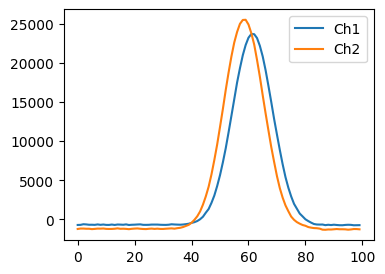

Delay: 2 (0.000000016 s) -> idx_max_1: 62, idx_max_2: 59


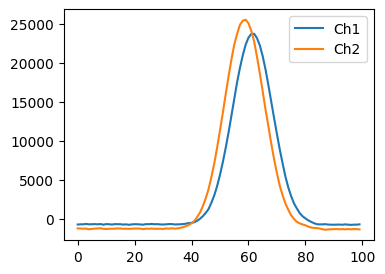

Delay: 4 (0.000000032 s) -> idx_max_1: 62, idx_max_2: 59


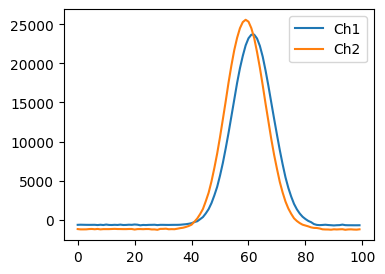

Delay: 8 (0.000000064 s) -> idx_max_1: 62, idx_max_2: 60


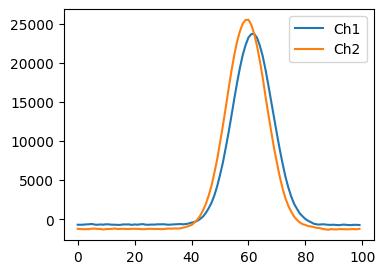

Delay: 16 (0.000000128 s) -> idx_max_1: 62, idx_max_2: 59


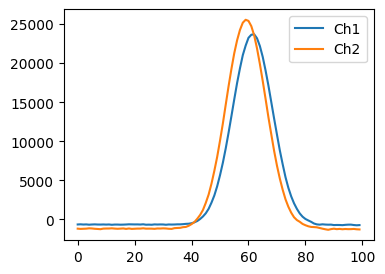

Delay: 32 (0.000000256 s) -> idx_max_1: 61, idx_max_2: 59


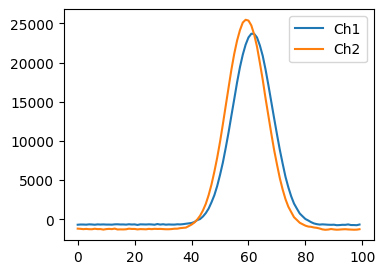

Delay: 64 (0.000000512 s) -> idx_max_1: 62, idx_max_2: 59


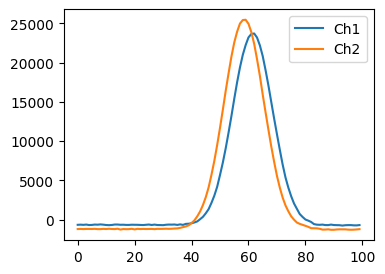

Delay: 128 (0.000001024 s) -> idx_max_1: 62, idx_max_2: 59


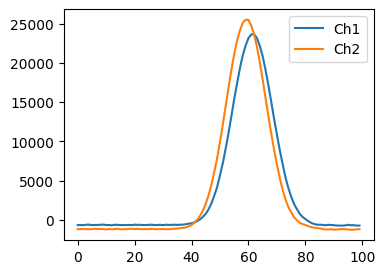

Delay: 256 (0.000002048 s) -> idx_max_1: 62, idx_max_2: 59


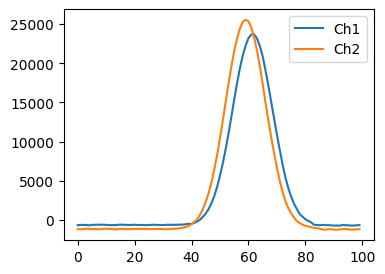

Delay: 512 (0.000004096 s) -> idx_max_1: 62, idx_max_2: 58


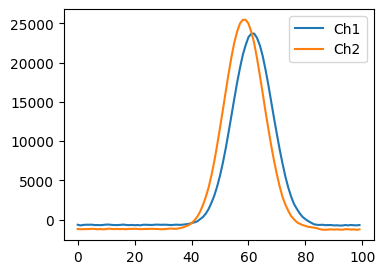

Delay: 1024 (0.000008192 s) -> idx_max_1: 62, idx_max_2: 59


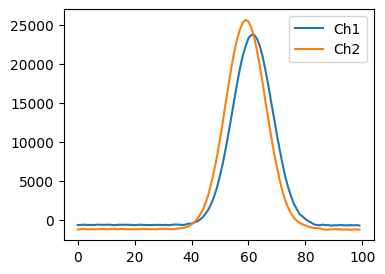

Delay: 2048 (0.000016384 s) -> idx_max_1: 62, idx_max_2: 59


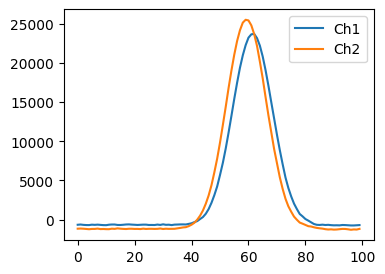

Delay: 4096 (0.000032768 s) -> idx_max_1: 61, idx_max_2: 58


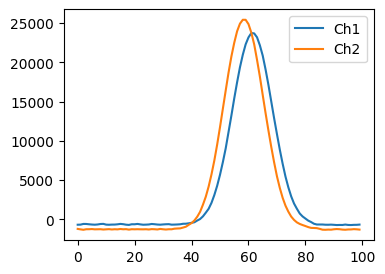

Delay: 8192 (0.000065536 s) -> idx_max_1: 62, idx_max_2: 59


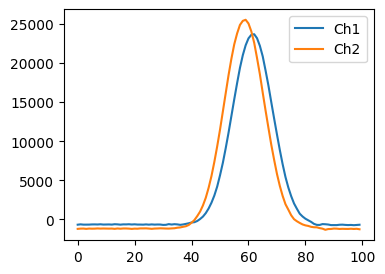

Delay: 16384 (0.000131072 s) -> idx_max_1: 61, idx_max_2: 59


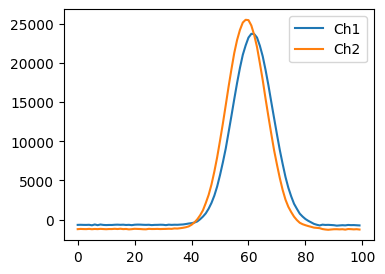

Delay: 32768 (0.000262144 s) -> idx_max_1: 61, idx_max_2: 59


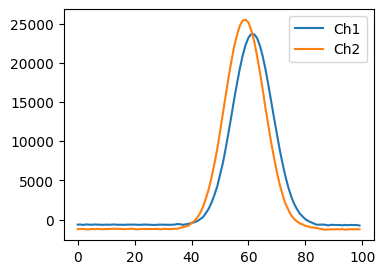

Delay: 65536 (0.000524288 s) -> idx_max_1: 62, idx_max_2: 59


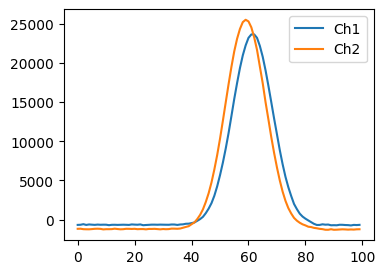

Delay: 131072 (0.001048576 s) -> idx_max_1: 61, idx_max_2: 58


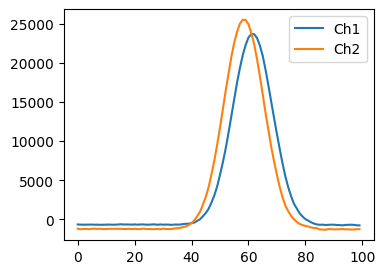

Delay: 262144 (0.002097152 s) -> idx_max_1: 62, idx_max_2: 58


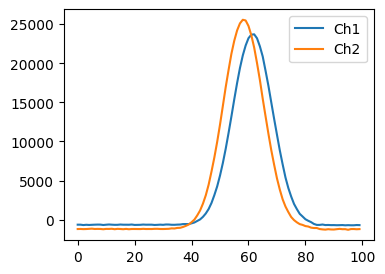

Delay: 524288 (0.004194304 s) -> idx_max_1: 61, idx_max_2: 58


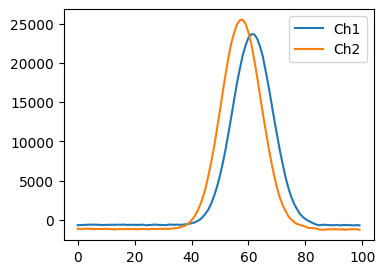

Delay: 1048576 (0.008388608 s) -> idx_max_1: 62, idx_max_2: 56


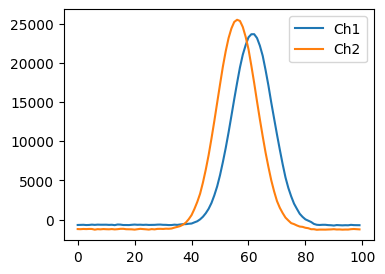

Delay: 2097152 (0.016777216 s) -> idx_max_1: 61, idx_max_2: 53


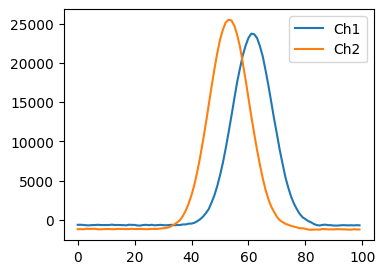

Delay: 4194304 (0.033554432 s) -> idx_max_1: 62, idx_max_2: 47


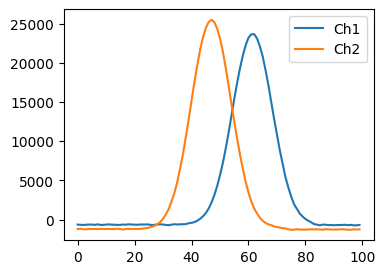

Delay: 8388608 (0.067108864 s) -> idx_max_1: 62, idx_max_2: 34


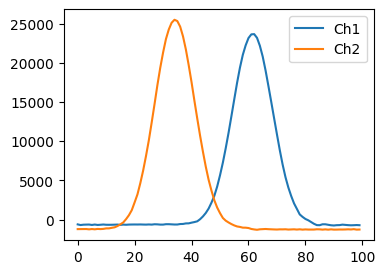

Delay: 16777216 (0.134217728 s) -> idx_max_1: 62, idx_max_2: 10


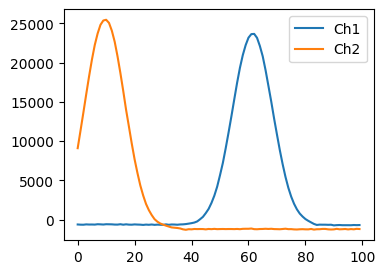

In [6]:

delay_list = 1 << np.arange(25)
waveform = 0.75 * np.exp(-np.linspace(-5, 5, 100)**2)

rp_acq = rp_0 #Select which device is used to acquire
rp_acq_id = rp_acq.get_uid()
clk_freq = rp_acq.CLK_FREQ #125 MH



for delay in delay_list:    
    fr_1.set_frame_parameter(delay=delay)
    fr_2.set_frame_parameter(waveform=waveform)
    fr_3.set_frame_parameter(waveform=waveform)
    
    seq.upload()
    seq.start()
    seq.wait()
    
    scope_dict = seq.get_scope()
      
    data_in_1_list = scope_dict[rp_acq_id]["RF in/out"]["scope_0"]["acq_ch_0"]["data"]
    data_in_2_list = scope_dict[rp_acq_id]["RF in/out"]["scope_1"]["acq_ch_1"]["data"]

    idx_max_1 = np.argmax(data_in_1_list)
    idx_max_2 = np.argmax(data_in_2_list)

    # Calculate cross-correlation to find max overlap
    correlation = np.correlate(data_in_1_list, data_in_2_list, mode='full')
    max_overlap_index = np.argmax(correlation)
    max_overlap_index = max_overlap_index - (len(data_in_1_list) - 1)  # Adjust index to account for 'full' mode
    print(f"Delay: {delay} ({delay/clk_freq:.9f} s) -> idx_max_1: {idx_max_1}, idx_max_2: {idx_max_2}")
    plt.figure(figsize=(4, 3))
    plt.plot(data_in_1_list, label="Ch1")
    plt.plot(data_in_2_list, label="Ch2")
    plt.legend(loc=1)
    plt.show()
    
